In [1]:
import re
import pandas as pd

path = r"F:\project\NCKH\Data\exports\all_review_with_all_label.xlsx"

# Đọc file Excel
df = pd.read_excel(path)

# Giới hạn hiển thị để không in tràn
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.expand_frame_repr", False)

# Đưa các cột *_label_[0-3] về % bằng cách chia cho review_count
if "review_count" not in df.columns:
    raise KeyError("Không tìm thấy cột 'review_count' trong file.")

review_count = pd.to_numeric(df["review_count"], errors="coerce")

label_cols = [c for c in df.columns if re.search(r"_label_[0-3]$", str(c))]

if not label_cols:
    print("Không tìm thấy cột dạng *_label_[0-3] để chuyển sang %.")
else:
    for col in label_cols:
        col_num = pd.to_numeric(df[col], errors="coerce")
        pct = (col_num / review_count) * 100
        pct = pct.where((review_count > 0) & review_count.notna(), other=0)
        df[f"{col}_pct"] = pct

    print("Đã tạo các cột % (suffix _pct) cho:", ", ".join(label_cols))

# In ra tất cả các cột sau xử lý
print("\nTổng số cột sau xử lý:", len(df.columns))
print("Tất cả các cột:")
print("\n".join(df.columns.astype(str)))


Đã tạo các cột % (suffix _pct) cho: content_label_0, content_label_1, content_label_2, content_label_3, physical_label_0, physical_label_1, physical_label_2, physical_label_3, price_label_0, price_label_1, price_label_2, price_label_3, packaging_label_0, packaging_label_1, packaging_label_2, packaging_label_3, delivery_label_0, delivery_label_1, delivery_label_2, delivery_label_3, service_label_0, service_label_1, service_label_2, service_label_3

Tổng số cột sau xử lý: 56
Tất cả các cột:
product_id
review_count
avg_rating
content_label_0
content_label_1
content_label_2
content_label_3
physical_label_0
physical_label_1
physical_label_2
physical_label_3
price_label_0
price_label_1
price_label_2
price_label_3
packaging_label_0
packaging_label_1
packaging_label_2
packaging_label_3
delivery_label_0
delivery_label_1
delivery_label_2
delivery_label_3
service_label_0
service_label_1
service_label_2
service_label_3
Sales Count
Discount Rate
label_count_0
label_count_1
label_count_2
content_lab

Số dòng dùng để tính Spearman: 1435
Spearman(Sales Count, review_count): 0.8461461479488771
Spearman(log1p_sales, review_count): 0.8461461479488771

Spearman rho (Sales Count vs feature) - sắp xếp theo |rho|:
              feature  spearman_rho
 delivery_label_0_pct      0.524169
  content_label_0_pct      0.499236
  service_label_0_pct      0.468014
packaging_label_0_pct      0.466297
    price_label_0_pct      0.399981
 physical_label_0_pct      0.378648

Spearman rho (log1p(Sales Count) vs feature) - sắp xếp theo |rho|:
              feature  spearman_rho
 delivery_label_0_pct      0.524169
  content_label_0_pct      0.499236
  service_label_0_pct      0.468014
packaging_label_0_pct      0.466297
    price_label_0_pct      0.399981
 physical_label_0_pct      0.378648

Spearman rho (review_count vs feature) - sắp xếp theo |rho|:
              feature  spearman_rho
 delivery_label_0_pct      0.591481
  content_label_0_pct      0.568179
packaging_label_0_pct      0.560898
  service_lab

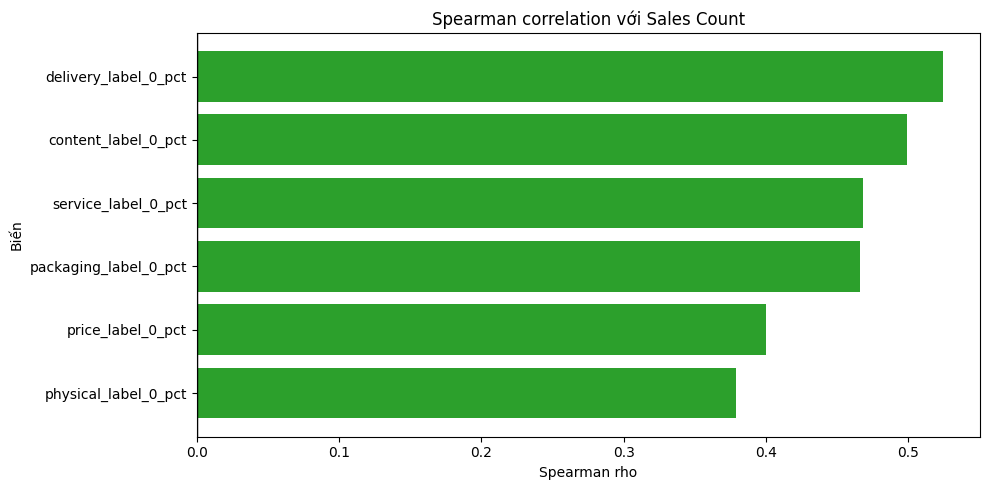

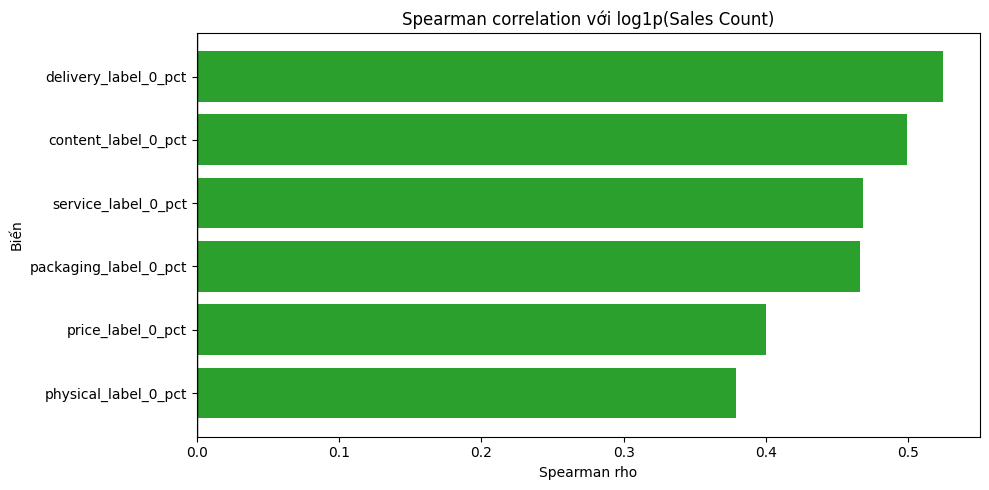

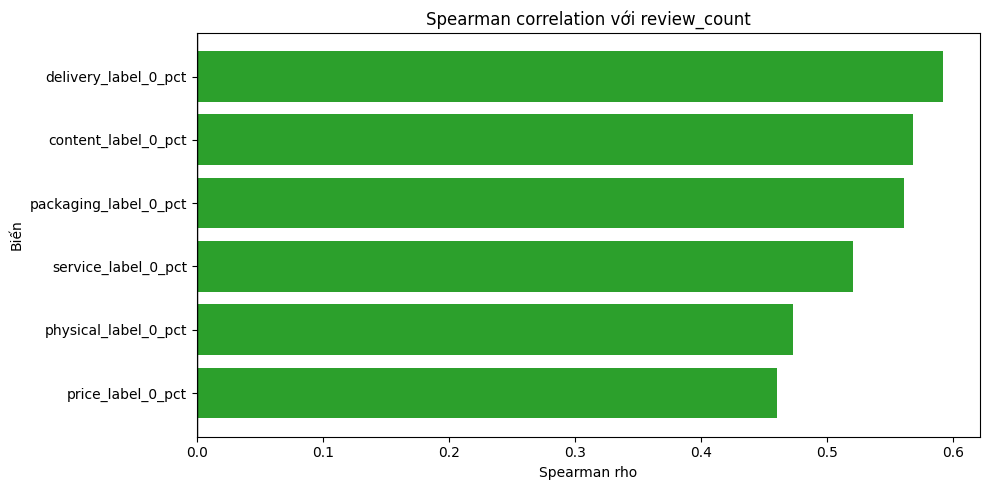

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ranking aspect "liên quan" bằng Spearman correlation
features = [
    "content_label_0_pct",
    "physical_label_0_pct",
    "price_label_0_pct",
    "packaging_label_0_pct",
    "delivery_label_0_pct",
    "service_label_0_pct",
]

needed_cols = ["Sales Count", "review_count", *features]
missing = [c for c in needed_cols if c not in df.columns]
if missing:
    raise KeyError(f"Thiếu cột trong df: {missing}")

model_df = df[needed_cols].copy()

# Ép kiểu numeric + drop missing
for c in needed_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")
model_df = model_df.dropna()

# Tạo log1p(Sales Count) để giảm lệch (clip tránh âm nếu dữ liệu bẩn)
model_df["log1p_sales"] = np.log1p(model_df["Sales Count"].clip(lower=0))


def spearman_rank(data: pd.DataFrame, target: str, feature_cols: list[str]) -> pd.DataFrame:
    rhos = []
    for c in feature_cols:
        rho = data[[target, c]].corr(method="spearman").iloc[0, 1]
        rhos.append(rho)
    out = pd.DataFrame({"feature": feature_cols, "spearman_rho": rhos})
    out["abs_rho"] = out["spearman_rho"].abs()
    return out.sort_values("abs_rho", ascending=False)


corr_sales = spearman_rank(model_df, "Sales Count", features)
corr_log_sales = spearman_rank(model_df, "log1p_sales", features)
corr_review_count = spearman_rank(model_df, "review_count", features)

rho_sales_vs_reviews = model_df[["Sales Count", "review_count"]].corr(method="spearman").iloc[0, 1]
rho_logsales_vs_reviews = model_df[["log1p_sales", "review_count"]].corr(method="spearman").iloc[0, 1]

print("Số dòng dùng để tính Spearman:", model_df.shape[0])
print("Spearman(Sales Count, review_count):", rho_sales_vs_reviews)
print("Spearman(log1p_sales, review_count):", rho_logsales_vs_reviews)

print("\nSpearman rho (Sales Count vs feature) - sắp xếp theo |rho|:")
print(corr_sales[["feature", "spearman_rho"]].to_string(index=False))

print("\nSpearman rho (log1p(Sales Count) vs feature) - sắp xếp theo |rho|:")
print(corr_log_sales[["feature", "spearman_rho"]].to_string(index=False))

print("\nSpearman rho (review_count vs feature) - sắp xếp theo |rho|:")
print(corr_review_count[["feature", "spearman_rho"]].to_string(index=False))


def plot_corr(corr_df: pd.DataFrame, title: str, xlabel: str):
    plt.figure(figsize=(10, 5))
    colors = ["#d62728" if v < 0 else "#2ca02c" for v in corr_df["spearman_rho"]]
    plt.barh(corr_df["feature"], corr_df["spearman_rho"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Biến")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


plot_corr(corr_sales, "Spearman correlation với Sales Count", "Spearman rho")
plot_corr(corr_log_sales, "Spearman correlation với log1p(Sales Count)", "Spearman rho")
plot_corr(corr_review_count, "Spearman correlation với review_count", "Spearman rho")
